In [1]:
import socket
print(socket.gethostname())

awr-2-15


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

### Pressure & Temperature

* **Mean sea level pressure (slp):** `mean_sea_level_pressure`
* **Surface pressure (p_sfc):** `surface_pressure`
* **2-m dewpoint temperature (Td_2m):** `2m_dewpoint_temperature`
* **2-m temperature (T_2m):** `2m_temperature`
* **Skin temperature (T_sfc):** `skin_temperature`
* **Sea surface temperature:** `sea_surface_temperature` *(Note: In ERA5, Skin Temperature is often used over land/ice, while SST is used over open ocean).*

### Moisture & Transport

* **Integrated water vapor (IWV):** `total_column_water_vapour`
* **Integrated vapor transport (meridional) (IVTV):** `vertical_integral_of_northward_water_vapour_flux`
* **Integrated vapor transport (zonal) (IVTU):** `vertical_integral_of_eastward_water_vapour_flux`

### Wind & Precipitation

* **10-m zonal wind (u_10m_gr):** `10m_u_component_of_wind`
* **10-m meridional wind (v_10m_gr):** `10m_v_component_of_wind`
* **6-hourly accumulated precipitation (precip_bkt):** `total_precipitation`

### Forcing
* **Geopotential at the surface (Z_sfc):** `geopotential_at_surface`

---

### Summary Table for Quick Reference

| Your Variable | ERA5 Equivalent Name |
| --- | --- |
| **slp** | `mean_sea_level_pressure` |
| **p_sfc** | `surface_pressure` |
| **Td_2m** | `2m_dewpoint_temperature` |
| **T_2m** | `2m_temperature` |
| **T_sfc** | `skin_temperature` / `sea_surface_temperature` |
| **IWV** | `total_column_water_vapour` |
| **IVTU / IVTV** | `vertical_integral_of_eastward/northward_water_vapour_flux` |
| **u_10m / v_10m** | `10m_u_component_of_wind` / `10m_v_component_of_wind` |
| **precip_bkt** | `total_precipitation` |
| **Z_sfc** |  `geopotential_at_surface` |

### Pressure-Level Variables (3D)

| Your Variable | ERA5 Equivalent Name | Dimensions |
| --- | --- | --- |
| **Geopotential (Z_e)** | `geopotential` | (time, level, latitude, longitude) |
| **Temperature (T_e)** | `temperature` | (time, level, latitude, longitude) |
| **Specific humidity (q_e)** | `specific_humidity` | (time, level, latitude, longitude) |
| **Zonal wind (u_gr_e)** | `u_component_of_wind` | (time, level, latitude, longitude) |
| **Meridional wind (v_gr_e)** | `v_component_of_wind` | (time, level, latitude, longitude) |



In [ ]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_native_vertical_grid_data = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T23:00:00.000000000'))

In [ ]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_full_37_1h = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T23:00:00.000000000'))

ar_model_level_and_surface_data = xr.merge([
    ar_native_vertical_grid_data, ar_full_37_1h.drop_dims('level')
])

In [ ]:
# 1. Define the variables we want to keep (using ERA5 names)
selected_vars = [
    "mean_sea_level_pressure", "surface_pressure", "2m_dewpoint_temperature",
    "2m_temperature", "skin_temperature", "total_column_water_vapour",
    "vertical_integral_of_eastward_water_vapour_flux", 
    "vertical_integral_of_northward_water_vapour_flux",
    "10m_u_component_of_wind", "10m_v_component_of_wind", 
    "total_precipitation", "geopotential", "temperature", 
    "specific_humidity", "u_component_of_wind", "v_component_of_wind",
    "geopotential_at_surface"
]

# 2. Select and Rename to match your desired shorthand
rename_map = {
    "mean_sea_level_pressure": "slp",
    "surface_pressure": "p_sfc",
    "2m_dewpoint_temperature": "Td_2m",
    "2m_temperature": "T_2m",
    "skin_temperature": "T_sfc", #TODO: confirm if this is the correct variable for skin temperature
    "total_column_water_vapour": "IWV",
    "vertical_integral_of_eastward_water_vapour_flux": "IVTU",
    "vertical_integral_of_northward_water_vapour_flux": "IVTV",
    "10m_u_component_of_wind": "u_10m_gr",
    "10m_v_component_of_wind": "v_10m_gr",
    "total_precipitation": "precip_bkt",
    "geopotential": "Z_e",
    "temperature": "T_e",
    "specific_humidity": "q_e",
    "u_component_of_wind": "u_gr_e",
    "v_component_of_wind": "v_gr_e",
    "geopotential_at_surface": "Z_sfc"
}

# Apply selection and renaming
ds_combined = ar_model_level_and_surface_data[selected_vars].rename(rename_map)

# 3. Resample to 6-hour intervals
# For precipitation, use sum
precip_resampled = ds_combined['precip_bkt'].resample(time='6h').sum()

# For other variables, use mean
others = ds_combined.drop_vars('precip_bkt')
others_resampled = others.resample(time='6h').mean()

# 4. Merge back the resampled data
ds_resampled = xr.merge([others_resampled, precip_resampled])

# 5. Save to NetCDF
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc'
ds_resampled.to_netcdf(save_path)

print(f"File successfully saved to {save_path}")

File successfully saved to /cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc


### Vertical Coordinate Alignment

The 13 selected hybrid sigma-pressure levels (`[15, 48, 68, 74, 79, 83, 90, 96, 101, 105, 114, 120, 133]`) weren't chosen randomly—they were mapped directly to your 13 constant pressure levels (`[1, 50, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000] hPa`). 

These 13 isobaric levels represent the standard standard meteorological atmospheric slices, allowing for straightforward synoptic analysis and comparison with observational sounding data. They are distributed to capture key atmospheric layers:

* **Planetary Boundary Layer & Near-Surface (1000, 925, 850 hPa):** Essential for capturing low-level moisture transport, surface heating, low-level jets, and conditions relevant to near-surface phenomena like wildfire risk.
* **Mid-Troposphere (700, 600, 500, 400 hPa):** The 500 hPa level dictates broad synoptic steering flows and vorticity advection, while 700 hPa is critical for tracking shortwaves, vertical motion, and mid-level moisture.
* **Upper Troposphere & Jet Stream (300, 250, 200, 150 hPa):** Tightly clustered to accurately resolve the kinematics of the polar and subtropical jet streams, upper-level divergence, and the tropopause boundary.
* **Stratosphere (50, 1 hPa):** Included to define the top of the atmospheric column and capture stratospheric wave interactions.

Since ERA5 natively uses 137 terrain-following hybrid levels, we just picked the specific IFS hybrid indices that correspond to the altitudes of those standard pressure surfaces. This guarantees you are comparing the exact same vertical slices of the atmosphere across both datasets. 


In [ ]:
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc'
ds = xr.open_dataset(save_path)
ds

In [ ]:
def plot_vertical_profiles(ds, variables=None, vertical_subset=None):
    """
    Plot vertical profiles for variables, comparing the full hybrid levels 
    against a specific subset of levels.
    """
    # Default vertical subset if none provided
    if vertical_subset is None:
        vertical_subset = [15, 48, 68, 74, 79, 83, 90, 96, 101, 105, 114, 120, 133]

    # Updated metadata using the exact keys from the parentheses
    var_metadata = {
        'Z_e': ('Geopotential', 'm²/s²'),
        'T_e': ('Temperature', 'K'),
        'q_e': ('Specific humidity', 'kg/kg'),
        'u_gr_e': ('Zonal wind', 'm/s'),
        'v_gr_e': ('Meridional wind', 'm/s')
    }

    # If no variables specified, use the shorthand keys from our metadata
    if variables is None:
        variables = list(var_metadata.keys())
        
    # Calculate grid weights once for the dataset
    weights = np.cos(np.deg2rad(ds.latitude))
    
    # Set consistent font sizes
    LABEL_SIZE = 12
    TICK_SIZE = 10
    LEGEND_SIZE = 10
    TITLE_SIZE = 14
    
    # Create figure layout
    n_vars = len(variables)
    n_cols = min(3, n_vars)  
    n_rows = int(np.ceil(n_vars / n_cols))
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(5*n_cols, 5*n_rows), 
                             constrained_layout=True)
    
    # Handle single subplot case
    if n_vars == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Loop through variables and create plots
    for i, var in enumerate(variables):
        # Skip if the variable isn't in the dataset
        if var not in ds.data_vars:
            print(f"Skipping {var} - not found in dataset.")
            continue
            
        ax = axes[i]
        
        # 1. Calculate weighted mean for the full grid
        ds_avg = ds[var].weighted(weights).mean(dim=("latitude", "longitude", "time"))
        
        # 2. Subset the averaged data based on the provided hybrid levels
        ds_subset = ds_avg.sel(hybrid=vertical_subset, method='nearest')
        
        # Get metadata for plotting 
        nice_name, units = var_metadata.get(var, (var, ''))
        
        # 3. Plot Original Grid
        ds_avg.plot(ax=ax, y='hybrid', yincrease=False, 
                    label='Original Grid', color='blue', alpha=0.7)
        
        # 4. Plot Subset (Regridded)
        ds_subset.plot(ax=ax, y='hybrid', yincrease=False, 
                       label='Regridded', color='red',
                       marker='x', markersize=8, linewidth=1.5, linestyle='')
        
        # Set labels and formatting
        if units:
            ax.set_xlabel(f'{units}', fontsize=LABEL_SIZE)
        ax.set_ylabel('Hybrid Levels', fontsize=LABEL_SIZE)
        
        # Combine the descriptive name and the shorthand key for a clear title
        ax.set_title(f'{nice_name}', fontsize=TITLE_SIZE)
        
        ax.tick_params(axis='x', labelsize=TICK_SIZE)
        ax.tick_params(axis='y', labelsize=TICK_SIZE)

        if var == 'Z_e':
            # scilimits=(3, 3) forces x10^3. useMathText makes it look like 10³ instead of 1e3
            ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3), useMathText=True)
            
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=LEGEND_SIZE)
    
    # Hide unused subplots if the grid isn't full
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    # plt.suptitle('Vertical Profiles: Full ERA5 vs Selected Hybrid Levels', fontsize=16, fontweight='bold')
    plt.show()

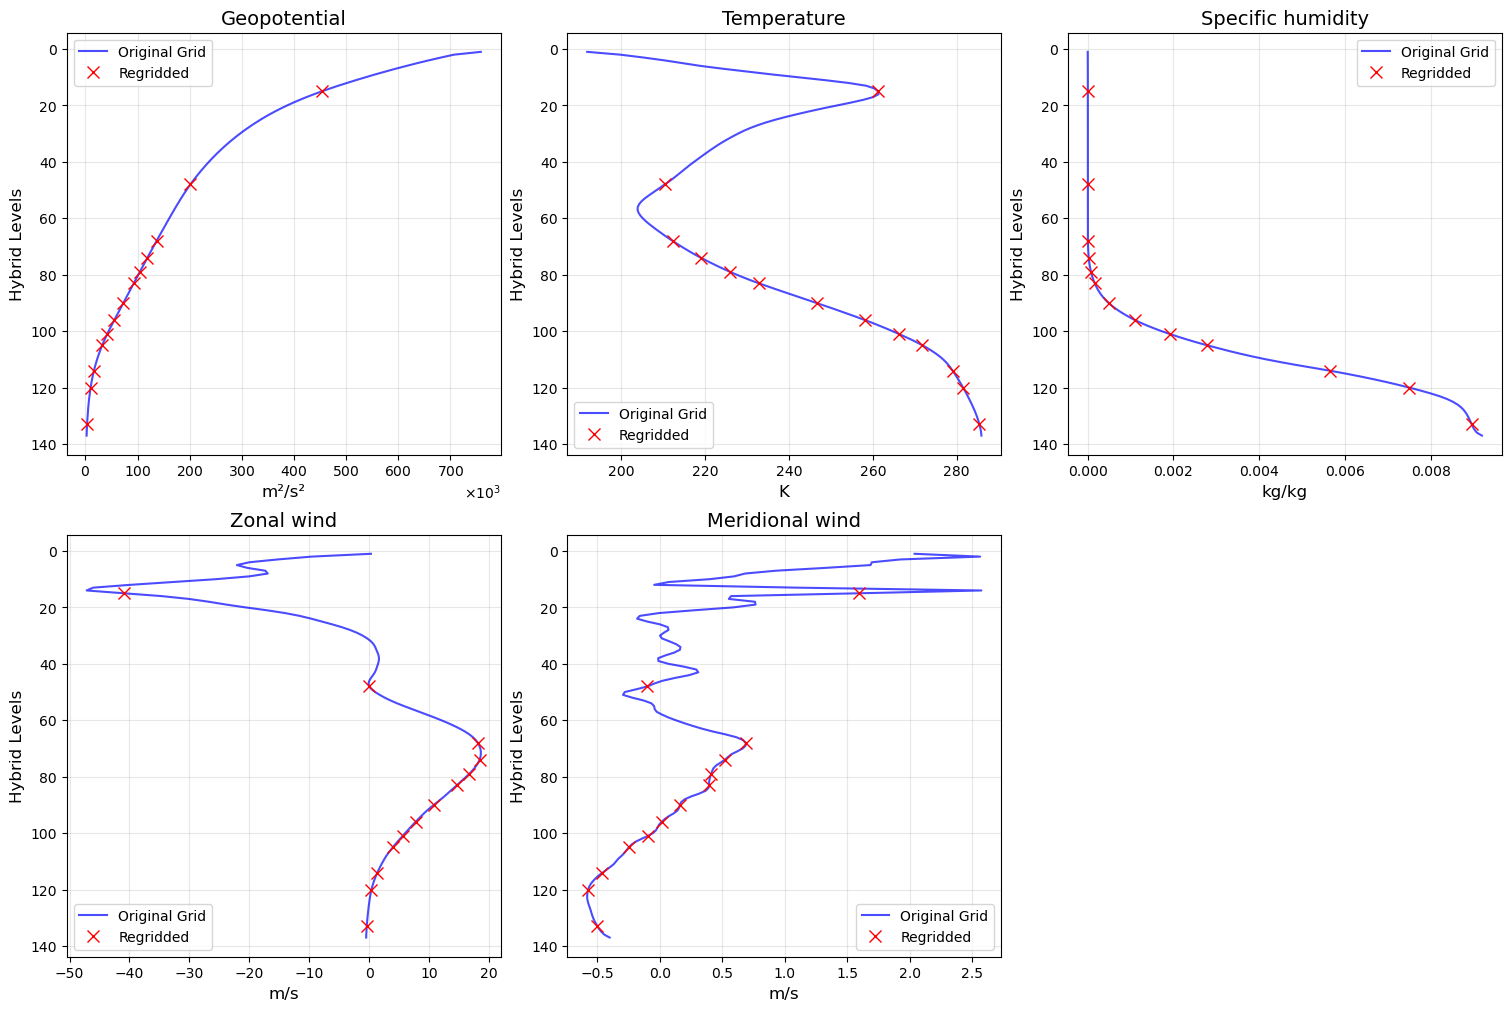

In [21]:
plot_vertical_profiles(ds)